<a href="https://colab.research.google.com/github/enm0910/ST554-HMWK3/blob/main/EMartinez_HW4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

####Author: Emma Martinez
####Course: ST 554
####Purpose: Homework 4- Practice summarizing data using pandas + matplotlib and advanced function writing

#Part 1- Summarizing Student Data Graphically

###Import libraries

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

###Import HW 3 data

####Task 1

In [44]:
# Read in student data and check first few observations
student_data = pd.read_csv('StudentData.dat', sep=';')
student_data.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


####Task 2- Contingency Tables

In [45]:
# Create a one-way contingency table & interpretation
school_table = pd.crosstab(index=student_data['school'], columns='count')
print(school_table)
print("Interpretation: There are 349 students from Gabriel Pereira (GP) school.")
print()

# Create a two-way contingency table & interpretation
school_sex_table = pd.crosstab(index=student_data['school'], columns=student_data['sex'])
print(school_sex_table)
print("Interpretation: There are 183 female students from GP school.")
print()

# Create a three-way contingency table & interpretation
three_way_table = pd.crosstab(index=[student_data['school'], student_data['sex']], columns=student_data['address'])
print(three_way_table)
print("Interpretation: There are 12 male students from MS school who live in rural areas.")
print()

col_0   count
school       
GP        349
MS         46
Interpretation: There are 349 students from Gabriel Pereira (GP) school.

sex       F    M
school          
GP      183  166
MS       25   21
Interpretation: There are 183 female students from GP school.

address      R    U
school sex         
GP     F    31  152
       M    32  134
MS     F    13   12
       M    12    9
Interpretation: There are 12 male students from MS school who live in rural areas.



####Task 2- Conditional Two-Way Table

In [46]:
# Conditional two-way table: Subsetting first using .loc
gp_students = student_data.loc[student_data['school'] == 'GP']
conditional_table_1 = pd.crosstab(index=gp_students['sex'], columns=gp_students['address'])
print("Conditional two-way table 1")
print(conditional_table_1)
print()

# Conditional two-way table: Create 3-way table then subset
three_way_full = pd.crosstab(index=[student_data['school'], student_data['sex']], columns=student_data['address'])
conditional_table_2 = three_way_full.loc['GP']
print("Conditional two-way table 2")
print(conditional_table_2)
print()

Conditional two-way table 1
address   R    U
sex             
F        31  152
M        32  134

Conditional two-way table 2
address   R    U
sex             
F        31  152
M        32  134



####Task 2- Numeric Variables (and Across Groups)

In [47]:
# Find measures of center and spread for three of variables (incl G3)
print("Age - Mean:", student_data['age'].mean())
print("Age - Std Dev:", student_data['age'].std())
print()
print("Absences - Mean:", student_data['absences'].mean())
print("Absences - Std Dev:", student_data['absences'].std())
print()
print("G3 - Mean:", student_data['G3'].mean())
print("G3 - Std Dev:", student_data['G3'].std())
print()

# Repeat while subsetting the data by grouping variable .loc
gp_data = student_data.loc[student_data['school'] == 'GP']
print("GP School - Age Mean:", gp_data['age'].mean())
print("GP School - Absences Mean:", gp_data['absences'].mean())
print("GP School - G3 Mean:", gp_data['G3'].mean())
print()

# Find measures of center and spread across a single grouping variable for three variables (incl G3)
grouped_sex = student_data.groupby('sex')[['age', 'absences', 'G3']].agg(['mean', 'std'])
print(grouped_sex)
print()

# Find measures of center and spread across two grouping variables for three variables (incl G3)
grouped_two = student_data.groupby(['school', 'sex'])[['age', 'absences', 'G3']].agg(['mean', 'std'])
print(grouped_two)
print()

# Create a correlation matrix between all numeric variables
correlation_matrix = student_data[['age', 'absences', 'G1', 'G2', 'G3']].corr()
print(correlation_matrix)

Age - Mean: 16.696202531645568
Age - Std Dev: 1.2760427246056245

Absences - Mean: 5.708860759493671
Absences - Std Dev: 8.003095687108177

G3 - Mean: 10.415189873417722
G3 - Std Dev: 4.5814426109978434

GP School - Age Mean: 16.521489971346703
GP School - Absences Mean: 5.965616045845272
GP School - G3 Mean: 10.489971346704872

           age            absences                   G3          
          mean       std      mean       std       mean       std
sex                                                              
F    16.730769  1.201696  6.216346  9.445819   9.966346  4.622338
M    16.657754  1.356181  5.144385  5.980749  10.914439  4.495297

                  age            absences                   G3          
                 mean       std      mean       std       mean       std
school sex                                                              
GP     F    16.579235  1.173426  6.639344  9.852259   9.972678  4.604622
       M    16.457831  1.263005  5.222892  6.2

###Task 1

####Categorical Variables

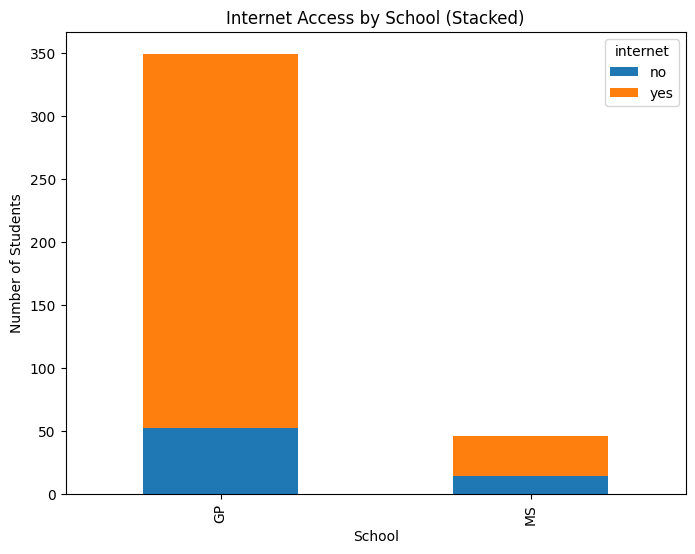

In [48]:
# Stacked bar graph
crosstab_stacked = pd.crosstab(student_data['school'], student_data['internet'])

crosstab_stacked.plot(kind='bar', stacked=True, figsize=(8, 6))
plt.xlabel('School')
plt.ylabel('Number of Students')
plt.title('Internet Access by School (Stacked)')
plt.show()

# Observations: This bar graph indicates that GP has significantly more students than MS and, as expected, a larger number of students have internet access

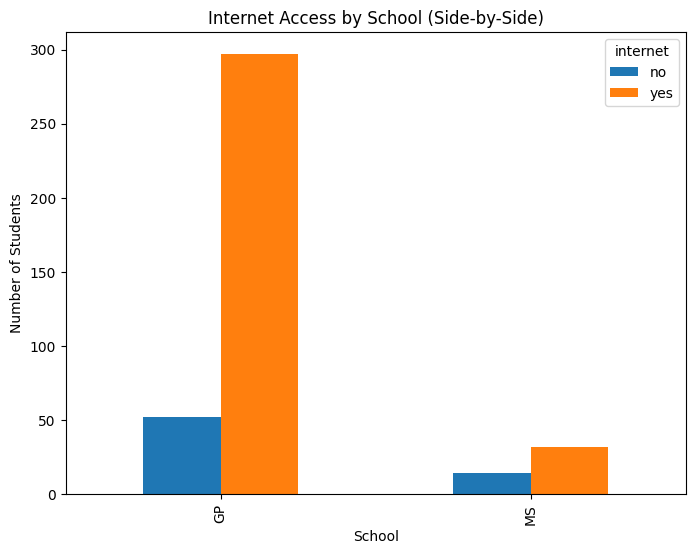

In [49]:
# Side-by-side bar graph
crosstab_sidebyside = pd.crosstab(student_data['school'], student_data['internet'])

crosstab_sidebyside.plot(kind='bar', stacked=False, figsize=(8, 6))
plt.xlabel('School')
plt.ylabel('Number of Students')
plt.title('Internet Access by School (Side-by-Side)')
plt.show()

# Observations: This bar graph indicates that for both schools (GP + MS), a majority of students have internet access.

####Numerical Variable: G3

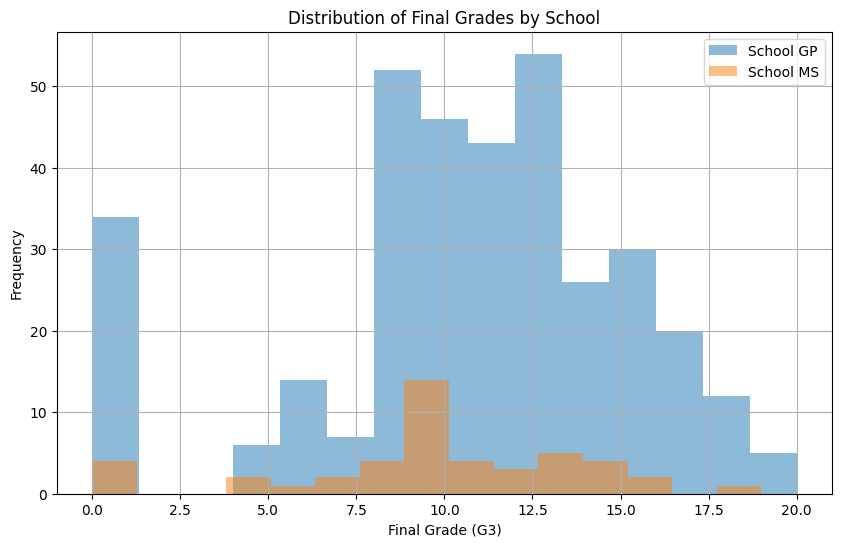

In [50]:
# Histogram of G3 by school
fig, ax = plt.subplots(figsize=(10, 6))

for school in student_data['school'].unique():
    subset = student_data[student_data['school'] == school]
    subset['G3'].hist(alpha=0.5, label=f'School {school}', bins=15, ax=ax)

plt.xlabel('Final Grade (G3)')
plt.ylabel('Frequency')
plt.title('Distribution of Final Grades by School')
plt.legend()
plt.show()

# Observations: This histogram shows that for both schools most students' scores are concentrated in the middle, indicating a higher density around these values.

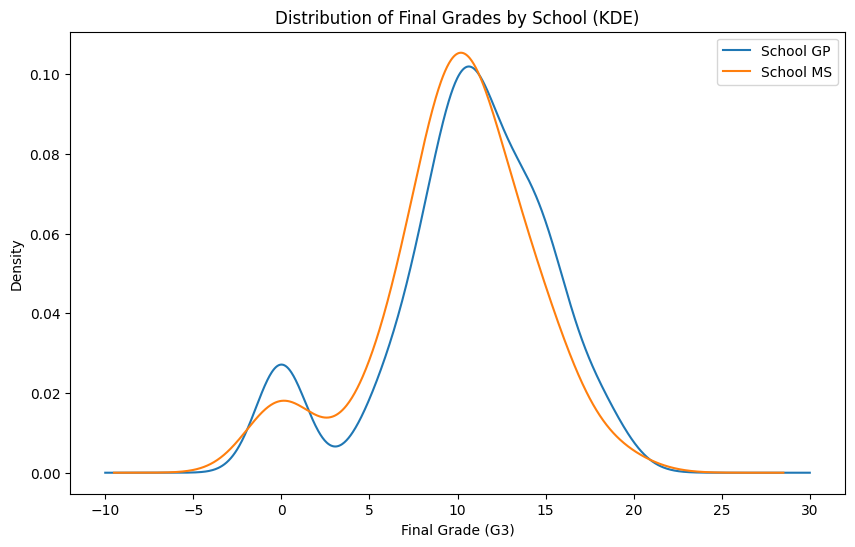

In [51]:
# Kernel density plot of G3 by school (overlayed)
fig, ax = plt.subplots(figsize=(10, 6))

for school in student_data['school'].unique():
    subset = student_data[student_data['school'] == school]
    subset['G3'].plot(kind='kde', label=f'School {school}', ax=ax)

plt.xlabel('Final Grade (G3)')
plt.ylabel('Density')
plt.title('Distribution of Final Grades by School (KDE)')
plt.legend()
plt.show()

# Observations: This layered kernel density plot indicates that GP appears to be bimodal, with a distinct peak at 0.
# This means a more students performed badly at GP than than MS.

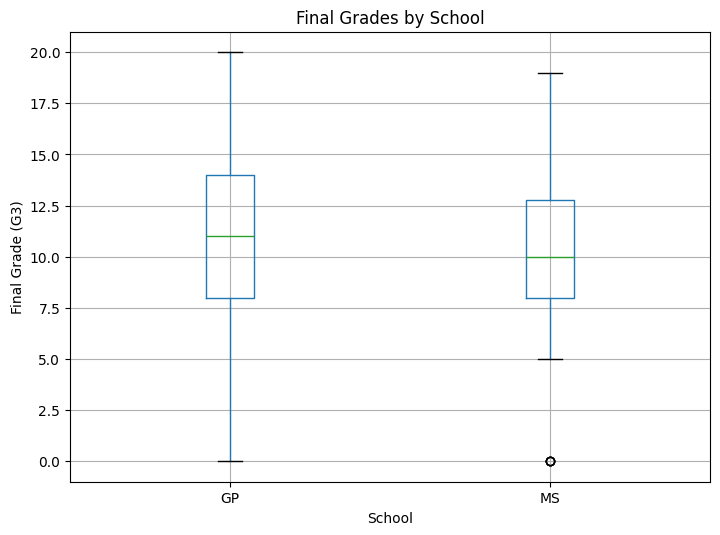

In [52]:
# Boxplot of G3 by school
student_data.boxplot(column='G3', by='school', figsize=(8, 6))
plt.xlabel('School')
plt.ylabel('Final Grade (G3)')
plt.title('Final Grades by School')
plt.suptitle('')
plt.show()

# Observations: This boxplot indicates that both schools have similar median grades, around 10-11 out of 20

####Numerical Variable: Absences

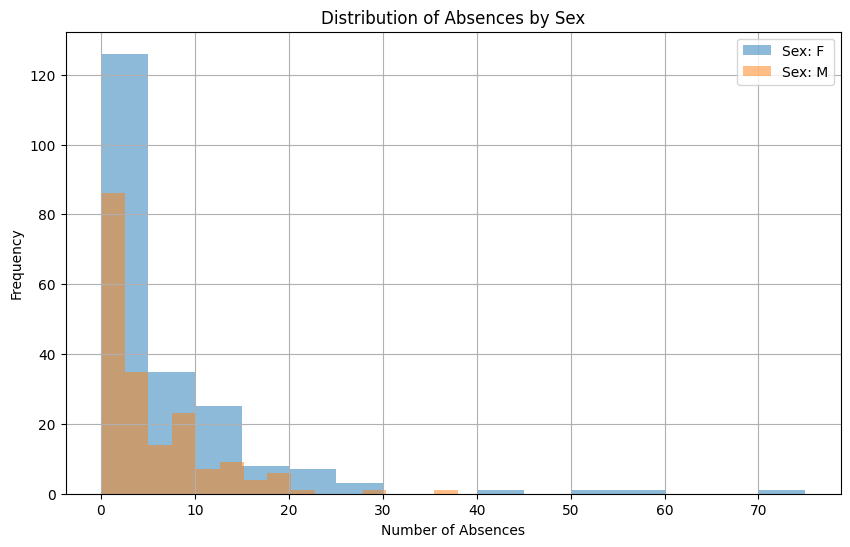

In [53]:
# Histogram of absences by sex
fig, ax = plt.subplots(figsize=(10, 6))

for sex in student_data['sex'].unique():
    subset = student_data[student_data['sex'] == sex]
    subset['absences'].hist(alpha=0.5, label=f'Sex: {sex}', bins=15, ax=ax)

plt.xlabel('Number of Absences')
plt.ylabel('Frequency')
plt.title('Distribution of Absences by Sex')
plt.legend()
plt.show()

# Observations: This histrogram indicates that more females than males had 0 absences.

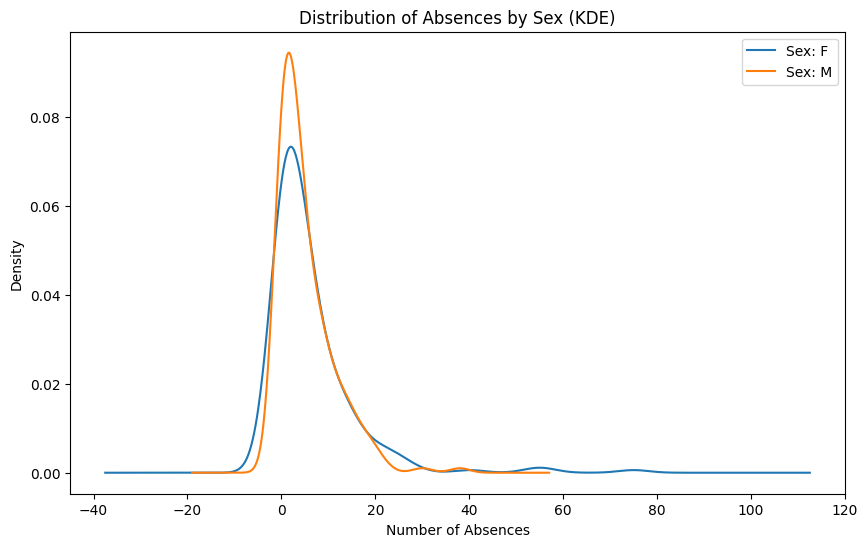

In [54]:
# Kernel density plot of absences by sex
fig, ax = plt.subplots(figsize=(10, 6))

for sex in student_data['sex'].unique():
    subset = student_data[student_data['sex'] == sex]
    subset['absences'].plot(kind='kde', label=f'Sex: {sex}', ax=ax)

plt.xlabel('Number of Absences')
plt.ylabel('Density')
plt.title('Distribution of Absences by Sex (KDE)')
plt.legend()
plt.show()

# Observations: This density plot indicates that the "females" line has a lower peak but extends further to the right.
# This suggests that female students have more variation in their absence patterns.

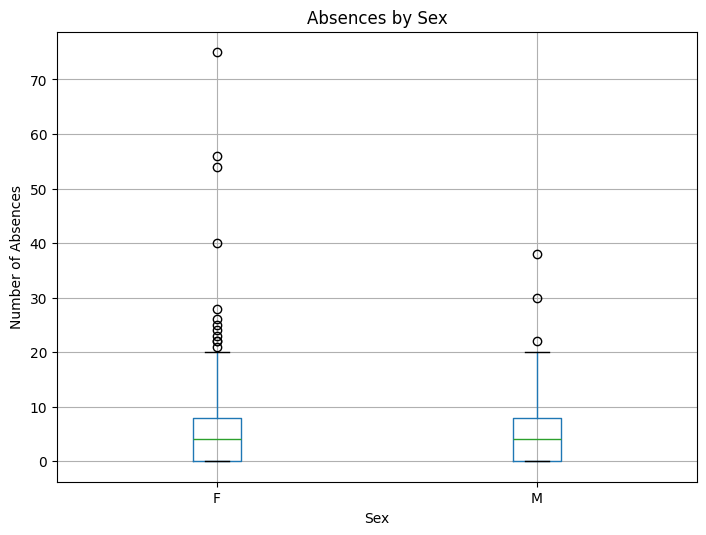

In [55]:
# Boxplot of absences by sex
student_data.boxplot(column='absences', by='sex', figsize=(8, 6))
plt.xlabel('Sex')
plt.ylabel('Number of Absences')
plt.title('Absences by Sex')
plt.suptitle('')
plt.show()

# Observations: This boxplot indicates that males and females both have similar median absences.
# Most students have very few absences.

####Numerical Variables: Scatterplots

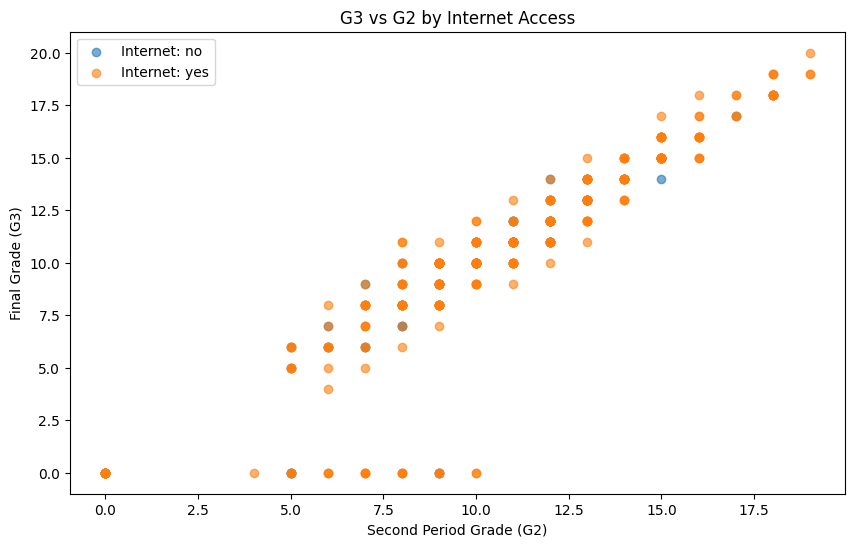

In [56]:
# Scatterplot: G3 vs G2, colored by internet
fig, ax = plt.subplots(figsize=(10, 6))

for internet in student_data['internet'].unique():
    subset = student_data[student_data['internet'] == internet]
    plt.scatter(subset['G2'], subset['G3'], label=f'Internet: {internet}', alpha=0.6)

plt.xlabel('Second Period Grade (G2)')
plt.ylabel('Final Grade (G3)')
plt.title('G3 vs G2 by Internet Access')
plt.legend()
plt.show()

# Observations: This scatterplot indicates that there is a positive correlation between G2 and G3.
# Students who scored well on the second period grade also scored well on the final grade.

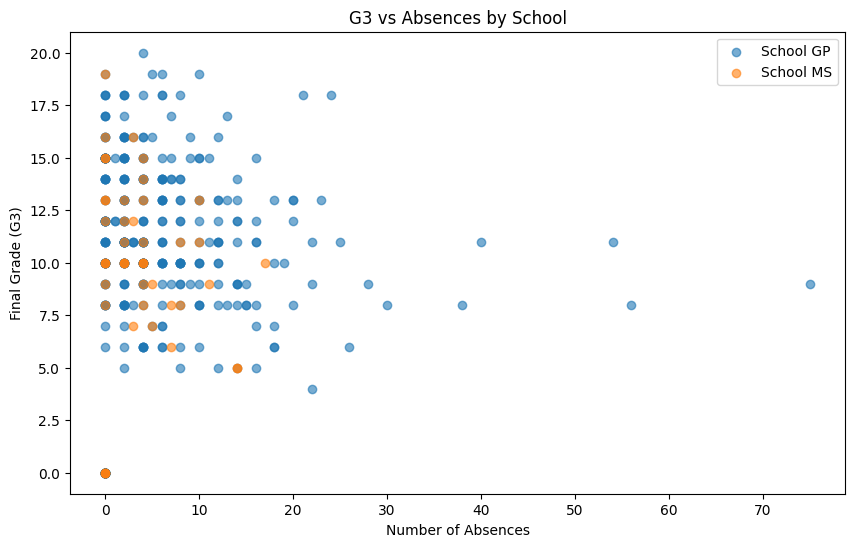

In [57]:
# Scatterplot: G3 vs absences, colored by school
fig, ax = plt.subplots(figsize=(10, 6))

for school in student_data['school'].unique():
    subset = student_data[student_data['school'] == school]
    plt.scatter(subset['absences'], subset['G3'], label=f'School {school}', alpha=0.6)

plt.xlabel('Number of Absences')
plt.ylabel('Final Grade (G3)')
plt.title('G3 vs Absences by School')
plt.legend()
plt.show()

# Observations: There's a slight negative correlation- as absences increase, final grades slightly decrease.
# Although the relationship is not very strong; however, students with fewer absences generally have higher scores.

#Part 2- Plotting the NFL Data

###Task 1- Read in the Data

In [58]:
# Read NFL data
nfl_url = "https://www4.stat.ncsu.edu/~online/datasets/scoresFull.csv"
nfl_data = pd.read_csv(nfl_url)

# Check first few observations
nfl_data.head()

,week,date,day,season,awayTeam,AQ1,AQ2,AQ3,AQ4,AOT,...,homeFumLost,homeNumPen,homePenYds,home3rdConv,home3rdAtt,home4thConv,home4thAtt,homeTOP,HminusAScore,homeSpread
0,1,5-Sep,Thu,2002,San Francisco 49ers,3,0,7,6,-1,...,0,10,80,4,8,0,1,32.47,-3,-4.0
1,1,8-Sep,Sun,2002,Minnesota Vikings,3,17,0,3,-1,...,1,4,33,2,6,0,0,28.48,4,4.5
2,1,8-Sep,Sun,2002,New Orleans Saints,6,7,7,0,6,...,0,8,85,1,6,0,1,31.48,-6,6.0
3,1,8-Sep,Sun,2002,New York Jets,0,17,3,11,6,...,1,10,82,4,8,2,2,39.13,-6,-3.0
4,1,8-Sep,Sun,2002,Arizona Cardinals,10,3,3,7,-1,...,0,7,56,6,10,1,2,34.40,8,6.0


In [59]:
# Convert to category type
nfl_data['homeTeam'] = nfl_data['homeTeam'].astype('category')
nfl_data['awayTeam'] = nfl_data['awayTeam'].astype('category')
nfl_data['day'] = nfl_data['day'].astype('category')
nfl_data['stadium'] = nfl_data['stadium'].astype('category')
nfl_data['startTime'] = nfl_data['startTime'].astype('category')
nfl_data['toss'] = nfl_data['toss'].astype('category')
nfl_data['roof'] = nfl_data['roof'].astype('category')
nfl_data['surface'] = nfl_data['surface'].astype('category')

###Task 2- Summarize the Data

In [60]:
# Convert week to numeric type
nfl_data['week'] = pd.to_numeric(nfl_data['week'], errors='coerce')

# Remove data where week is not 1 thru 17
nfl_regular = nfl_data[(nfl_data['week'] >= 1) & (nfl_data['week'] <= 17)].copy()

In [61]:
# Summary by season + week
season_week_summary = nfl_regular.groupby(['season', 'week']).agg({
    'HFinal': 'mean',
    'AFinal': 'mean',
    'HtotalYds': 'mean'})

season_week_summary.head(20)

HFinal     AFinal   HtotalYds
season week                                  
2002   1.0   26.125000  23.125000  348.625000
       2.0   18.187500  22.687500  306.812500
       3.0   24.428571  19.571429  322.571429
       4.0   28.285714  18.928571  346.857143
       5.0   23.214286  24.000000  341.571429
       6.0   20.785714  23.285714  344.785714
       7.0   24.857143  15.928571  342.214286
       8.0   21.857143  20.142857  310.785714
       9.0   15.928571  23.142857  283.571429
       10.0  22.571429  23.500000  374.857143
       11.0  22.562500  18.375000  344.312500
       12.0  21.000000  21.187500  329.375000
       13.0  25.000000  19.062500  339.250000
       14.0  25.625000  21.437500  343.812500
       15.0  24.687500  20.562500  328.187500
       16.0  19.312500  18.375000  314.875000
       17.0  23.062500  16.562500  331.250000
2003   1.0   23.250000  17.062500  314.937500
       2.0   22.812500  22.375000  314.062500
       3.0   18.214286  19.142857  312.857143

In [62]:
# Summary by season
season_summary = nfl_regular.groupby('season').agg({
    'HFinal': ['mean', 'median'],
    'AFinal': ['mean', 'median'],
    'HtotalYds': 'mean'})

season_summary

HFinal            AFinal          HtotalYds
             mean median       mean median        mean
season                                                
2002    22.796875   23.0  20.550781   20.5  332.519531
2003    22.609375   23.0  19.054688   19.0  330.015625
2004    22.738281   23.0  20.230469   19.0  333.742188
2005    22.441406   21.0  18.792969   19.0  323.871094
2006    21.082031   20.0  20.234375   21.0  327.597656
2007    23.121094   22.0  20.253906   20.0  327.589844
2008    23.308594   24.0  20.750000   20.0  335.062500
2009    22.570312   23.0  20.363281   20.0  347.171875
2010    22.984375   23.0  21.089844   20.0  342.707031
2011    23.812500   23.0  20.546875   20.0  352.816406
2012    23.972656   23.0  21.539062   21.5  349.058594
2013    24.960938   24.0  21.855469   21.0  357.195312
2014    23.832031   23.0  21.343750   21.0  351.535156

In [63]:
# Summary by week
week_summary = nfl_regular.groupby('week').agg({
    'HFinal': 'mean',
    'AFinal': 'mean',
    'Hturnovers': 'mean'})

week_summary

,HFinal,AFinal,Hturnovers
week,,,
1.0,22.139423,19.716346,1.682692
2.0,22.840580,19.545894,1.574879
3.0,22.646465,20.767677,1.712121
4.0,24.092391,20.983696,1.625000
5.0,24.324176,20.527473,1.620879
6.0,22.988950,20.679558,1.707182
7.0,23.338889,21.111111,1.583333
8.0,23.359551,20.151685,1.483146
9.0,22.258427,22.146067,1.578652


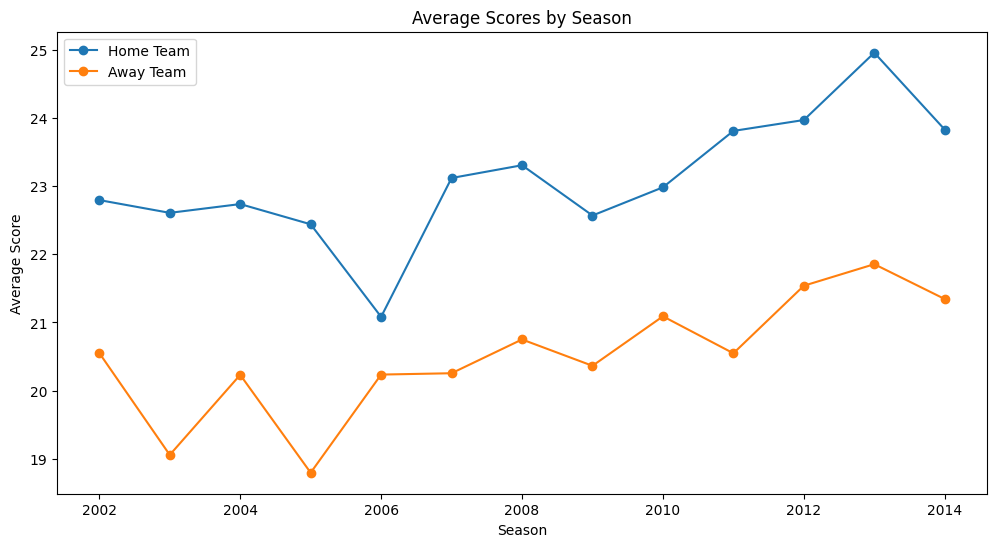

In [64]:
# Plot average scores by season
season_scores = nfl_regular.groupby('season')[['HFinal', 'AFinal']].mean()

plt.figure(figsize=(12, 6))
plt.plot(season_scores.index, season_scores['HFinal'], marker='o', label='Home Team')
plt.plot(season_scores.index, season_scores['AFinal'], marker='o', label='Away Team')
plt.xlabel('Season')
plt.ylabel('Average Score')
plt.title('Average Scores by Season')
plt.legend()
plt.show()

# Observations: Although home team consistently scored more, both home and away teams scores are steadily increasing over time.

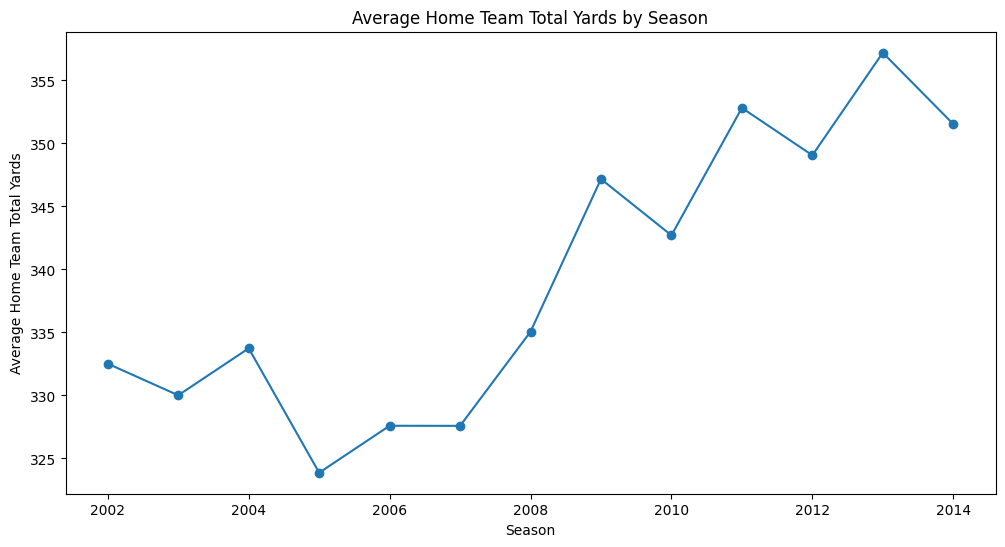

In [65]:
# Plot average total yards by season
season_yards = nfl_regular.groupby('season')['HtotalYds'].mean()

plt.figure(figsize=(12, 6))
plt.plot(season_yards.index, season_yards.values, marker='o')
plt.xlabel('Season')
plt.ylabel('Average Home Team Total Yards')
plt.title('Average Home Team Total Yards by Season')
plt.show()

# Observations: There is an overall increase in average home team total yards from 2002 (approx 332 yds) to 2013 (approx 357 yds).
# This indicates that offenses have improved over time.

In [66]:
# Create timeit decorator
import time
from functools import wraps

def timeit(func):
    @wraps(func)
    def wrapper(*args, **kwargs):
        start = time.time()
        result = func(*args, **kwargs)
        end = time.time()
        print(f"Time taken: {end - start:.4f} seconds")
        return result
    return wrapper

In [67]:
# Function with type hints and decorator
@timeit
def plot_average_by_season(data: pd.DataFrame, variable: str):
    """
    Plot the average of a variable across seasons.

    Parameters:
    data: DataFrame with NFL data
    variable: Name of numeric column to plot
    """
    season_avg = data.groupby('season')[variable].mean()

    plt.figure(figsize=(12, 6))
    plt.plot(season_avg.index, season_avg.values, marker='o')
    plt.xlabel('Season')
    plt.ylabel(f'Average {variable}')
    plt.title(f'Average {variable} by Season')
    plt.show()

####Run the function 3 times

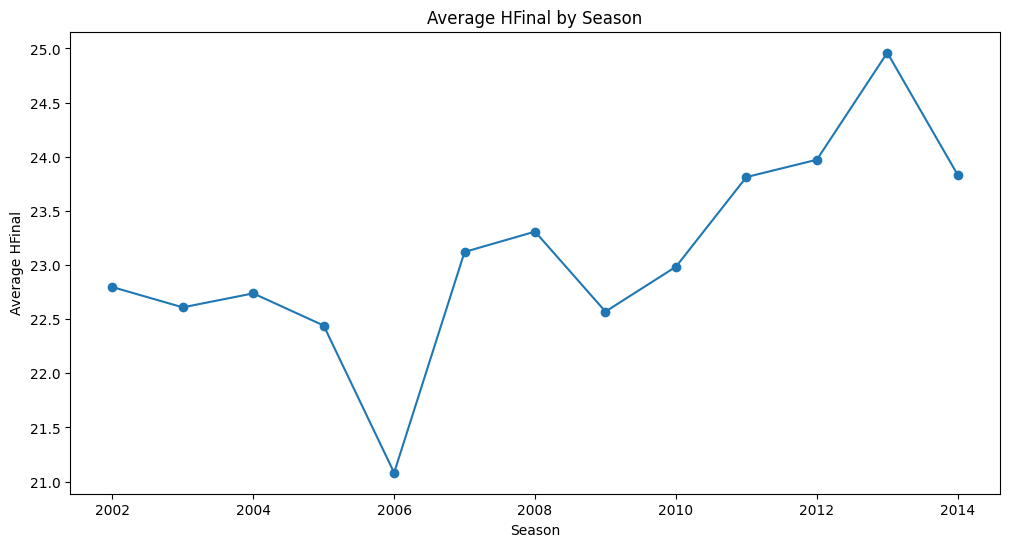

Time taken: 0.1731 seconds


In [68]:
# First run
plot_average_by_season(nfl_regular, 'HFinal')

# Observations: There is a sharp decline in scores in 2006, indicating a serious issue on the team.
# Since the scores steadily increase after 2006, this indicates that the team rebounded from whatever problem occured in 2006.

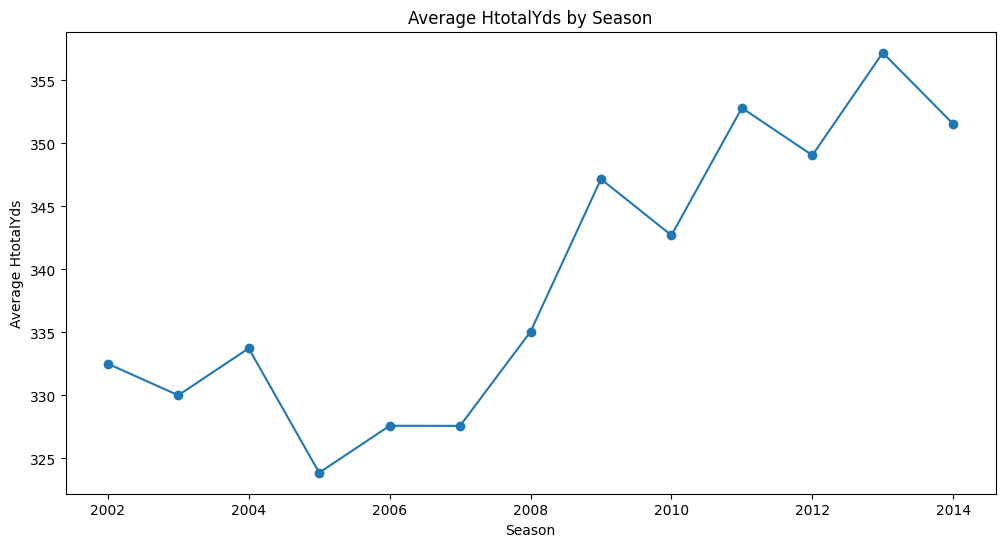

Time taken: 0.1611 seconds


In [69]:
# Second run
plot_average_by_season(nfl_regular, 'HtotalYds')

# Observations: Avg home team total yds show an upward trend from 2002 to 2013, increasing from about 332 yards to 357 yards per game.

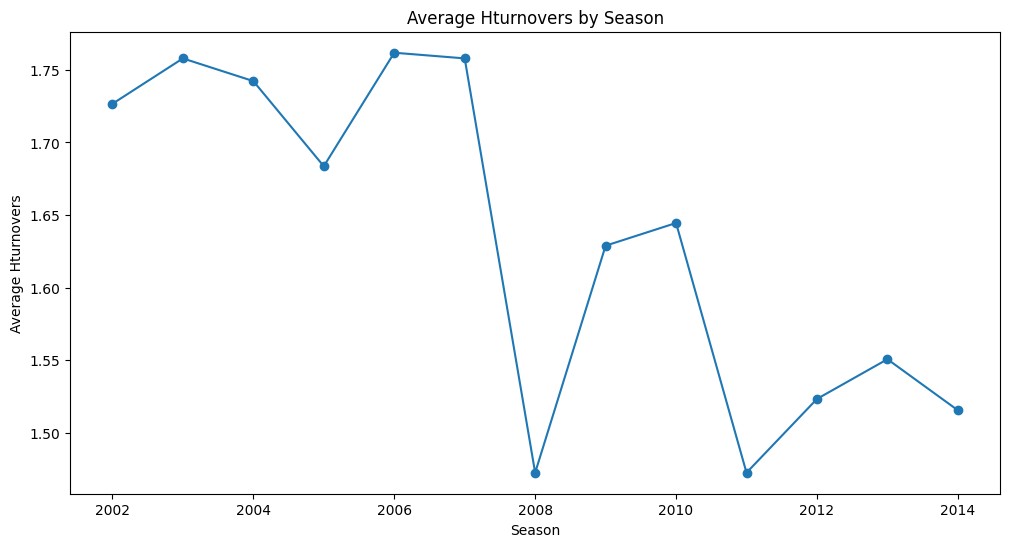

Time taken: 0.1593 seconds


In [70]:
# Third run
plot_average_by_season(nfl_regular, 'Hturnovers')

# Observations: Avg turnovers decreased from approx 1.73 / game in 2002 to approx 1.52 / game in 2014.
# This shows that home teams are protecting the ball better over time.